In [1]:
# ============================================================
# PHASE 11 — REPEATED-SPLIT / MULTI-SEED ROBUSTNESS EVALUATION
# ============================================================
# Goal:
# 1. Address supervisor/reviewer concern about relying on one held-out split.
# 2. Re-run selected final models across multiple random seeds.
# 3. Report mean ± SD across repeated splits.
# 4. Use PR-AUC as primary ranking metric.
# 5. Use MCC as primary threshold-dependent metric.
# 6. Treat ROC-AUC and F1 as secondary metrics.
# ============================================================

import os
import json
import time
import joblib
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)
from sklearn.base import clone

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

SEED_GLOBAL = 42
np.random.seed(SEED_GLOBAL)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
PHASE5_DIR = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE9_DIR = PROJECT_DIR / "model" / "phase9_dnabert2_behaviour_deep_dive"
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"

PHASE11_DIR = PROJECT_DIR / "model" / "phase11_repeated_split_seed_robustness"
RESULT_DIR = PHASE11_DIR / "results"
FIGURE_DIR = PHASE11_DIR / "figures"
MODEL_DIR = PHASE11_DIR / "models"
EXCEL_DIR = PHASE11_DIR / "excel"
REPORT_DIR = PHASE11_DIR / "reports"

for folder in [PHASE11_DIR, RESULT_DIR, FIGURE_DIR, MODEL_DIR, EXCEL_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 11 output:", PHASE11_DIR)

Mounted at /content/drive
Phase 11 output: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Recommended publication-ready setting: 10 seeds minimum.
# Start with 5 seeds for debugging, then increase to 10 or 20.
REPEATED_SPLIT_SEEDS = [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]

TEST_SIZE = 0.15
VAL_SIZE = 0.15
TRAIN_SIZE = 0.70

# Validation threshold selection
# MCC is primary threshold-dependent metric.
THRESHOLD_SELECTION_METRIC = "mcc"

# To save time, use SVM for all final feature representations.
# This matches the main final SVM-based comparison used in Phase 3/5.
MODEL_FAMILY = "svm_rbf"

# SVM selected hyperparameters.
# These are reasonable and consistent with your previous SVM RBF setup.
# If you have exact best params from earlier, you can replace C/gamma.
SVM_C = 1.0
SVM_GAMMA = "scale"

# Use class_weight=None because dataset is balanced.
CLASS_WEIGHT = None

# Maximum rows expected. Your shared multimodal dataset should be around 1806 genes.
EXPECTED_MIN_N = 1500

print("Seeds:", REPEATED_SPLIT_SEEDS)
print("Train/Val/Test:", TRAIN_SIZE, VAL_SIZE, TEST_SIZE)
print("Primary ranking metric: PR-AUC")
print("Primary threshold metric: MCC")

Seeds: [11, 22, 33, 44, 55, 66, 77, 88, 99, 111]
Train/Val/Test: 0.7 0.15 0.15
Primary ranking metric: PR-AUC
Primary threshold metric: MCC


In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_gene_symbol(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def find_files(root, suffixes=(".csv", ".npy", ".pkl"), keywords=None):
    root = Path(root)
    if not root.exists():
        return []

    results = []

    for suffix in suffixes:
        for p in root.rglob(f"*{suffix}"):
            name = str(p).lower()
            if keywords is not None:
                if not all(k.lower() in name for k in keywords):
                    continue
            results.append(p)

    return sorted(results)


def inspect_npy(path):
    path = Path(path)
    arr = np.load(path, mmap_mode="r")
    return arr.shape


def safe_read_csv(path):
    path = Path(path)
    assert path.exists(), f"Missing CSV: {path}"
    return pd.read_csv(path)


def make_svm_pipeline(seed):
    return Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=SVM_C,
            gamma=SVM_GAMMA,
            probability=False,
            class_weight=CLASS_WEIGHT,
            random_state=seed
        ))
    ])


def get_continuous_score(model, X):
    """
    Ranking metrics need continuous scores.
    For SVM, decision_function is preferred.
    """
    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    return model.predict(X)


def compute_ranking_metrics(y_true, y_score):
    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


def compute_classification_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def select_threshold_on_validation(y_val, score_val, metric="mcc"):
    """
    Select threshold using validation set only.
    This avoids tuning threshold on test set.
    """
    candidate_thresholds = np.unique(np.quantile(
        score_val,
        np.linspace(0.01, 0.99, 99)
    ))

    best_threshold = 0.0
    best_value = -np.inf

    for thr in candidate_thresholds:
        y_pred = (score_val >= thr).astype(int)

        if metric == "mcc":
            value = matthews_corrcoef(y_val, y_pred)
        elif metric == "f1":
            value = f1_score(y_val, y_pred, zero_division=0)
        else:
            raise ValueError("Unsupported threshold metric")

        if value > best_value:
            best_value = value
            best_threshold = float(thr)

    return best_threshold, best_value


def split_train_val_test_indices(y, seed, test_size=0.15, val_size=0.15):
    """
    Stratified split:
    70% train, 15% validation, 15% test.
    """
    idx_all = np.arange(len(y))

    idx_trainval, idx_test, y_trainval, y_test = train_test_split(
        idx_all,
        y,
        test_size=test_size,
        stratify=y,
        random_state=seed
    )

    val_relative_size = val_size / (1.0 - test_size)

    idx_train, idx_val, y_train, y_val = train_test_split(
        idx_trainval,
        y_trainval,
        test_size=val_relative_size,
        stratify=y_trainval,
        random_state=seed
    )

    return idx_train, idx_val, idx_test


def summarise_mean_sd(df, group_cols, metric_cols):
    records = []

    for keys, sub in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_cols, keys))
        record["n_runs"] = sub.shape[0]

        for metric in metric_cols:
            record[f"{metric}_mean"] = sub[metric].mean()
            record[f"{metric}_sd"] = sub[metric].std(ddof=1)
            record[f"{metric}_median"] = sub[metric].median()
            record[f"{metric}_min"] = sub[metric].min()
            record[f"{metric}_max"] = sub[metric].max()

        records.append(record)

    return pd.DataFrame(records)


def paired_seed_comparison(df, model_a, model_b, metric):
    """
    Compare model_b - model_a across repeated seeds.
    This is not a formal paired bootstrap; it is a repeated-split paired summary.
    """
    a = df[df["model_key"] == model_a][["seed", metric]].rename(columns={metric: "metric_a"})
    b = df[df["model_key"] == model_b][["seed", metric]].rename(columns={metric: "metric_b"})

    merged = a.merge(b, on="seed", how="inner")
    merged["delta_b_minus_a"] = merged["metric_b"] - merged["metric_a"]

    return {
        "model_a": model_a,
        "model_b": model_b,
        "metric": metric,
        "n_paired_seeds": merged.shape[0],
        "metric_a_mean": merged["metric_a"].mean(),
        "metric_b_mean": merged["metric_b"].mean(),
        "delta_mean": merged["delta_b_minus_a"].mean(),
        "delta_sd": merged["delta_b_minus_a"].std(ddof=1),
        "delta_median": merged["delta_b_minus_a"].median(),
        "n_seeds_better": int((merged["delta_b_minus_a"] > 0).sum()),
        "n_seeds_worse": int((merged["delta_b_minus_a"] < 0).sum()),
        "n_seeds_equal": int((merged["delta_b_minus_a"] == 0).sum()),
        "delta_values": ";".join([f"{x:.6f}" for x in merged["delta_b_minus_a"].tolist()])
    }

In [4]:
# ============================================================
# LOCATE CANDIDATE FULL DATA FILES
# ============================================================

print("=== Candidate metadata CSV files ===")
metadata_candidates = []

for root in [PHASE3_DIR, PHASE5_DIR, PROJECT_DIR / "model"]:
    metadata_candidates.extend(
        find_files(
            root,
            suffixes=(".csv",),
            keywords=["metadata"]
        )
    )

for p in metadata_candidates[:80]:
    print(" -", p)

print("\n=== Candidate full protein feature NPY files ===")
protein_candidates = []
for root in [PHASE3_DIR, PROJECT_DIR / "model"]:
    protein_candidates.extend(
        find_files(
            root,
            suffixes=(".npy",),
            keywords=["protein"]
        )
    )

for p in protein_candidates:
    try:
        shape = inspect_npy(p)
    except Exception:
        shape = "cannot inspect"
    print(" -", p, shape)

print("\n=== Candidate handcrafted genomic feature NPY files ===")
genomic_candidates = []
for root in [PHASE3_DIR, PROJECT_DIR / "model"]:
    genomic_candidates.extend(
        find_files(
            root,
            suffixes=(".npy",),
            keywords=["genomic"]
        )
    )

for p in genomic_candidates:
    try:
        shape = inspect_npy(p)
    except Exception:
        shape = "cannot inspect"
    print(" -", p, shape)

print("\n=== Candidate DNABERT-2 feature NPY files ===")
dnabert_candidates = []
for root in [PHASE5_DIR, PROJECT_DIR / "model"]:
    dnabert_candidates.extend(
        find_files(
            root,
            suffixes=(".npy",),
            keywords=["dnabert"]
        )
    )

for p in dnabert_candidates:
    try:
        shape = inspect_npy(p)
    except Exception:
        shape = "cannot inspect"
    print(" -", p, shape)

=== Candidate metadata CSV files ===
 - /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/all_shared_multimodal_metadata_v1.csv
 - /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/test_multimodal_metadata_v1.csv
 - /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/train_multimodal_metadata_v1.csv
 - /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/val_multimodal_metadata_v1.csv
 - /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_test_dnabert2_sw2048_stride1024_embedding_metadata.csv
 - /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_test_dnabert2_sw2048_stride1024_partial_metadata.csv
 - /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_dnabert2_sw2048_stride1024_embedding_metadata.csv
 - /c

In [5]:
# ============================================================
# PHASE 11 FIXED CELL 5
# SET EXACT SPLIT-BASED PATHS
# ============================================================
# Your files are split into train / val / test.
# We will concatenate them into one full dataset, then re-split repeatedly.

# Metadata
META_TRAIN_PATH = PHASE3_DIR / "shared_dataset" / "train_multimodal_metadata_v1.csv"
META_VAL_PATH   = PHASE3_DIR / "shared_dataset" / "val_multimodal_metadata_v1.csv"
META_TEST_PATH  = PHASE3_DIR / "shared_dataset" / "test_multimodal_metadata_v1.csv"

META_ALL_PATH   = PHASE3_DIR / "shared_dataset" / "all_shared_multimodal_metadata_v1.csv"

# Labels
Y_TRAIN_PATH = PHASE3_DIR / "shared_dataset" / "y_train_multimodal_v1.npy"
Y_VAL_PATH   = PHASE3_DIR / "shared_dataset" / "y_val_multimodal_v1.npy"
Y_TEST_PATH  = PHASE3_DIR / "shared_dataset" / "y_test_multimodal_v1.npy"

# Protein features
X_TRAIN_PROTEIN_PATH = PHASE3_DIR / "features" / "X_train_protein_protbert_sw_v1.npy"
X_VAL_PROTEIN_PATH   = PHASE3_DIR / "features" / "X_val_protein_protbert_sw_v1.npy"
X_TEST_PROTEIN_PATH  = PHASE3_DIR / "features" / "X_test_protein_protbert_sw_v1.npy"

# Handcrafted multimodal combined features: protein 1024 + genomic K3/K4/Basic 356 = 1380
X_TRAIN_COMBINED_HAND_PATH = PHASE3_DIR / "features" / "X_train_combined_protein_genomic_v1.npy"
X_VAL_COMBINED_HAND_PATH   = PHASE3_DIR / "features" / "X_val_combined_protein_genomic_v1.npy"
X_TEST_COMBINED_HAND_PATH  = PHASE3_DIR / "features" / "X_test_combined_protein_genomic_v1.npy"

# DNABERT-2 multimodal combined features: protein 1024 + DNABERT-2 768 = 1792
PHASE5_EMBED_DIR = PHASE5_DIR / "embeddings"

X_TRAIN_COMBINED_DNA_PATH = PHASE5_EMBED_DIR / "X_train_combined_protbert_sw_dnabert2_v1.npy"
X_VAL_COMBINED_DNA_PATH   = PHASE5_EMBED_DIR / "X_val_combined_protbert_sw_dnabert2_v1.npy"
X_TEST_COMBINED_DNA_PATH  = PHASE5_EMBED_DIR / "X_test_combined_protbert_sw_dnabert2_v1.npy"

# DNABERT-2 genomic-only embeddings
X_TRAIN_DNABERT2_PATH = PHASE5_EMBED_DIR / "X_train_dnabert2_sw2048_stride1024_embeddings.npy"
X_VAL_DNABERT2_PATH   = PHASE5_EMBED_DIR / "X_val_dnabert2_sw2048_stride1024_embeddings.npy"
X_TEST_DNABERT2_PATH  = PHASE5_EMBED_DIR / "X_test_dnabert2_sw2048_stride1024_embeddings.npy"

# Handcrafted genomic-only features are not separately available for train/val in your file list.
# But we can extract them from combined handcrafted matrix:
# combined_hand = [protein 1024 columns + genomic 356 columns]
PROTEIN_DIM = 1024

paths_to_check = [
    META_TRAIN_PATH, META_VAL_PATH, META_TEST_PATH,
    Y_TRAIN_PATH, Y_VAL_PATH, Y_TEST_PATH,
    X_TRAIN_PROTEIN_PATH, X_VAL_PROTEIN_PATH, X_TEST_PROTEIN_PATH,
    X_TRAIN_COMBINED_HAND_PATH, X_VAL_COMBINED_HAND_PATH, X_TEST_COMBINED_HAND_PATH,
    X_TRAIN_COMBINED_DNA_PATH, X_VAL_COMBINED_DNA_PATH, X_TEST_COMBINED_DNA_PATH,
    X_TRAIN_DNABERT2_PATH, X_VAL_DNABERT2_PATH, X_TEST_DNABERT2_PATH,
]

missing = [str(p) for p in paths_to_check if not Path(p).exists()]

if missing:
    print("Missing files:")
    for p in missing:
        print(" -", p)
    raise FileNotFoundError("Some required split-based files are missing.")

print("All split-based paths exist.")

All split-based paths exist.


In [7]:
# ============================================================
# PHASE 11 FIXED CELL 6
# LOAD AND CONCATENATE TRAIN / VAL / TEST
# ============================================================

# Metadata
meta_train = pd.read_csv(META_TRAIN_PATH)
meta_val   = pd.read_csv(META_VAL_PATH)
meta_test  = pd.read_csv(META_TEST_PATH)

meta_train["original_split"] = "train"
meta_val["original_split"] = "val"
meta_test["original_split"] = "test"

metadata_df = pd.concat([meta_train, meta_val, meta_test], axis=0, ignore_index=True)

# Labels
y_train = np.load(Y_TRAIN_PATH)
y_val   = np.load(Y_VAL_PATH)
y_test  = np.load(Y_TEST_PATH)

y = np.concatenate([y_train, y_val, y_test], axis=0).astype(int)

# Protein features
X_train_protein = np.load(X_TRAIN_PROTEIN_PATH)
X_val_protein   = np.load(X_VAL_PROTEIN_PATH)
X_test_protein  = np.load(X_TEST_PROTEIN_PATH)

X_protein = np.concatenate(
    [X_train_protein, X_val_protein, X_test_protein],
    axis=0
)

# Handcrafted combined features
X_train_combined_hand = np.load(X_TRAIN_COMBINED_HAND_PATH)
X_val_combined_hand   = np.load(X_VAL_COMBINED_HAND_PATH)
X_test_combined_hand  = np.load(X_TEST_COMBINED_HAND_PATH)

X_combined_hand = np.concatenate(
    [X_train_combined_hand, X_val_combined_hand, X_test_combined_hand],
    axis=0
)

# Extract handcrafted genomic-only features from combined handcrafted matrix
# combined_hand = protein 1024 + genomic 356
X_genomic_hand = X_combined_hand[:, PROTEIN_DIM:]

# DNABERT-2 genomic-only features
X_train_dnabert2 = np.load(X_TRAIN_DNABERT2_PATH)
X_val_dnabert2   = np.load(X_VAL_DNABERT2_PATH)
X_test_dnabert2  = np.load(X_TEST_DNABERT2_PATH)

X_genomic_dnabert2 = np.concatenate(
    [X_train_dnabert2, X_val_dnabert2, X_test_dnabert2],
    axis=0
)

# DNABERT-2 combined features
X_train_combined_dna = np.load(X_TRAIN_COMBINED_DNA_PATH)
X_val_combined_dna   = np.load(X_VAL_COMBINED_DNA_PATH)
X_test_combined_dna  = np.load(X_TEST_COMBINED_DNA_PATH)

X_combined_dnabert2 = np.concatenate(
    [X_train_combined_dna, X_val_combined_dna, X_test_combined_dna],
    axis=0
)

print("metadata_df:", metadata_df.shape)
print("y:", y.shape)

print("X_protein:", X_protein.shape)
print("X_genomic_hand:", X_genomic_hand.shape)
print("X_combined_hand:", X_combined_hand.shape)
print("X_genomic_dnabert2:", X_genomic_dnabert2.shape)
print("X_combined_dnabert2:", X_combined_dnabert2.shape)

# Basic consistency checks
n = len(y)

assert metadata_df.shape[0] == n, "Metadata and y length mismatch."
assert X_protein.shape[0] == n, "Protein feature row mismatch."
assert X_genomic_hand.shape[0] == n, "Handcrafted genomic feature row mismatch."
assert X_combined_hand.shape[0] == n, "Handcrafted combined feature row mismatch."
assert X_genomic_dnabert2.shape[0] == n, "DNABERT-2 genomic feature row mismatch."
assert X_combined_dnabert2.shape[0] == n, "DNABERT-2 combined feature row mismatch."

assert X_protein.shape[1] == 1024, "Protein feature dimension should be 1024."
assert X_genomic_hand.shape[1] == 356, "Handcrafted genomic feature dimension should be 356."
assert X_combined_hand.shape[1] == 1380, "Handcrafted combined feature dimension should be 1380."
assert X_genomic_dnabert2.shape[1] == 768, "DNABERT-2 genomic feature dimension should be 768."
assert X_combined_dnabert2.shape[1] == 1792, "DNABERT-2 combined feature dimension should be 1792."

print("\nLabel distribution:")
print(pd.Series(y).value_counts().sort_index())

print("\nOriginal split distribution:")
print(metadata_df["original_split"].value_counts())

display(metadata_df.head())

metadata_df: (1806, 13)
y: (1806,)
X_protein: (1806, 1024)
X_genomic_hand: (1806, 356)
X_combined_hand: (1806, 1380)
X_genomic_dnabert2: (1806, 768)
X_combined_dnabert2: (1806, 1792)

Label distribution:
0    903
1    903
Name: count, dtype: int64

Original split distribution:
original_split
train    1264
val       271
test      271
Name: count, dtype: int64


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,original_split
0,ENSG00000128607,KLHDC10,0,1667,test,KLHDC10,0,89,train,True,0,KLHDC10,train
1,ENSG00000146374,RSPO3,1,1030,train,RSPO3,1,518,train,True,1,RSPO3,train
2,ENSG00000163159,VPS72,0,1193,train,VPS72,0,298,train,True,0,VPS72,train
3,ENSG00000115020,PIKFYVE,0,265,train,PIKFYVE,0,747,train,True,0,PIKFYVE,train
4,ENSG00000164588,HCN1,1,633,train,HCN1,1,197,train,True,1,HCN1,train


In [8]:
# ============================================================
# PHASE 11 FIXED CELL 7
# STANDARDISE METADATA COLUMNS
# ============================================================

# Ensure gene_id
if "gene_id" not in metadata_df.columns:
    candidate_gene_id_cols = [
        "ensembl_gene_id",
        "gene",
        "GeneID",
        "id"
    ]

    found = None
    for c in candidate_gene_id_cols:
        if c in metadata_df.columns:
            found = c
            break

    if found is not None:
        metadata_df["gene_id"] = metadata_df[found]
    else:
        metadata_df["gene_id"] = metadata_df.index.astype(str)

# Ensure gene_symbol
if "gene_symbol" not in metadata_df.columns:
    candidate_symbol_cols = [
        "symbol",
        "gene_name",
        "Gene",
        "GeneSymbol"
    ]

    found = None
    for c in candidate_symbol_cols:
        if c in metadata_df.columns:
            found = c
            break

    if found is not None:
        metadata_df["gene_symbol"] = metadata_df[found]
    else:
        metadata_df["gene_symbol"] = metadata_df["gene_id"]

metadata_df["gene_id"] = metadata_df["gene_id"].astype(str)
metadata_df["gene_symbol"] = metadata_df["gene_symbol"].astype(str).str.strip()
metadata_df["gene_symbol_upper"] = metadata_df["gene_symbol"].apply(normalize_gene_symbol)
metadata_df["true_label"] = y.astype(int)

# Save reconstructed full dataset metadata
reconstructed_meta_path = RESULT_DIR / "phase11_reconstructed_full_metadata_from_train_val_test.csv"
metadata_df.to_csv(reconstructed_meta_path, index=False)

print("Saved:", reconstructed_meta_path)
display(metadata_df[["gene_id", "gene_symbol", "gene_symbol_upper", "true_label", "original_split"]].head())

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_reconstructed_full_metadata_from_train_val_test.csv


,gene_id,gene_symbol,gene_symbol_upper,true_label,original_split
0,ENSG00000128607,KLHDC10,KLHDC10,0,train
1,ENSG00000146374,RSPO3,RSPO3,1,train
2,ENSG00000163159,VPS72,VPS72,0,train
3,ENSG00000115020,PIKFYVE,PIKFYVE,0,train
4,ENSG00000164588,HCN1,HCN1,1,train


In [9]:
# ============================================================
# PHASE 11 FIXED CELL 8
# BUILD FEATURE SETS FROM RECONSTRUCTED FULL DATASET
# ============================================================

FEATURE_SETS = {
    "Protein_only_ProtBERT_SW": {
        "X": X_protein,
        "description": "Protein-only ProtBERT sliding-window embedding",
    },
    "Genomic_only_K3K4Basic": {
        "X": X_genomic_hand,
        "description": "Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix",
    },
    "Multimodal_handcrafted": {
        "X": X_combined_hand,
        "description": "ProtBERT-SW + handcrafted K3/K4/Basic genomic features",
    },
    "Multimodal_DNABERT2": {
        "X": X_combined_dnabert2,
        "description": "ProtBERT-SW + DNABERT-2 genomic embedding",
    },
}

for model_key, obj in FEATURE_SETS.items():
    print(model_key, obj["X"].shape, "|", obj["description"])

# Optional: save reconstructed full features for future use
SAVE_RECONSTRUCTED_FEATURES = True

if SAVE_RECONSTRUCTED_FEATURES:
    reconstructed_feature_dir = PHASE11_DIR / "reconstructed_full_features"
    reconstructed_feature_dir.mkdir(parents=True, exist_ok=True)

    np.save(reconstructed_feature_dir / "X_all_protein_protbert_sw_v1.npy", X_protein)
    np.save(reconstructed_feature_dir / "X_all_genomic_k3k4basic_extracted_v1.npy", X_genomic_hand)
    np.save(reconstructed_feature_dir / "X_all_combined_protein_genomic_v1.npy", X_combined_hand)
    np.save(reconstructed_feature_dir / "X_all_genomic_dnabert2_sw2048_stride1024_v1.npy", X_genomic_dnabert2)
    np.save(reconstructed_feature_dir / "X_all_combined_protbert_sw_dnabert2_v1.npy", X_combined_dnabert2)
    np.save(reconstructed_feature_dir / "y_all_multimodal_v1.npy", y)

    print("Saved reconstructed full feature files to:", reconstructed_feature_dir)

Protein_only_ProtBERT_SW (1806, 1024) | Protein-only ProtBERT sliding-window embedding
Genomic_only_K3K4Basic (1806, 356) | Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix
Multimodal_handcrafted (1806, 1380) | ProtBERT-SW + handcrafted K3/K4/Basic genomic features
Multimodal_DNABERT2 (1806, 1792) | ProtBERT-SW + DNABERT-2 genomic embedding
Saved reconstructed full feature files to: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/reconstructed_full_features


In [10]:
# ============================================================
# RUN REPEATED-SPLIT EVALUATION
# ============================================================

all_run_records = []
all_prediction_records = []
split_composition_records = []

start_time = time.time()

for seed in REPEATED_SPLIT_SEEDS:
    print("=" * 100)
    print("Running seed:", seed)

    idx_train, idx_val, idx_test = split_train_val_test_indices(
        y=y,
        seed=seed,
        test_size=TEST_SIZE,
        val_size=VAL_SIZE
    )

    y_train = y[idx_train]
    y_val = y[idx_val]
    y_test = y[idx_test]

    split_composition_records.append({
        "seed": seed,
        "n_train": len(idx_train),
        "n_val": len(idx_val),
        "n_test": len(idx_test),
        "train_pos": int(y_train.sum()),
        "train_neg": int((y_train == 0).sum()),
        "val_pos": int(y_val.sum()),
        "val_neg": int((y_val == 0).sum()),
        "test_pos": int(y_test.sum()),
        "test_neg": int((y_test == 0).sum()),
    })

    for model_key, feature_obj in FEATURE_SETS.items():
        print("  Model:", model_key)

        X = feature_obj["X"]

        X_train = X[idx_train]
        X_val = X[idx_val]
        X_test = X[idx_test]

        model = make_svm_pipeline(seed=seed)

        model.fit(X_train, y_train)

        val_score = get_continuous_score(model, X_val)
        test_score = get_continuous_score(model, X_test)

        selected_threshold, val_threshold_metric = select_threshold_on_validation(
            y_val=y_val,
            score_val=val_score,
            metric=THRESHOLD_SELECTION_METRIC
        )

        ranking_metrics = compute_ranking_metrics(y_test, test_score)

        class_metrics = compute_classification_metrics(
            y_true=y_test,
            y_score=test_score,
            threshold=selected_threshold
        )

        record = {
            "seed": seed,
            "model_key": model_key,
            "model_description": feature_obj["description"],
            "n_train": len(idx_train),
            "n_val": len(idx_val),
            "n_test": len(idx_test),
            "n_features": X.shape[1],
            "selected_threshold": selected_threshold,
            "validation_threshold_metric": THRESHOLD_SELECTION_METRIC,
            "validation_threshold_metric_value": val_threshold_metric,
            **ranking_metrics,
            **class_metrics
        }

        all_run_records.append(record)

        # Save test predictions for downstream analysis
        test_meta = metadata_df.iloc[idx_test][[
            "gene_id",
            "gene_symbol",
            "gene_symbol_upper",
            "true_label"
        ]].copy()

        test_meta["seed"] = seed
        test_meta["model_key"] = model_key
        test_meta["score"] = test_score
        test_meta["selected_threshold"] = selected_threshold
        test_meta["pred_label"] = (test_score >= selected_threshold).astype(int)
        test_meta["error_type"] = [
            "TP" if yt == 1 and yp == 1 else
            "TN" if yt == 0 and yp == 0 else
            "FP" if yt == 0 and yp == 1 else
            "FN"
            for yt, yp in zip(test_meta["true_label"], test_meta["pred_label"])
        ]

        all_prediction_records.append(test_meta)

        # Save model
        model_out_path = MODEL_DIR / f"phase11_{model_key}_seed{seed}.pkl"
        joblib.dump(model, model_out_path)

        print(
            f"    ROC-AUC={ranking_metrics['roc_auc']:.4f} | "
            f"PR-AUC={ranking_metrics['pr_auc']:.4f} | "
            f"MCC={class_metrics['mcc']:.4f} | "
            f"threshold={selected_threshold:.4f}"
        )

elapsed = time.time() - start_time

print("\nFinished repeated-split evaluation.")
print("Elapsed seconds:", round(elapsed, 2))

Running seed: 11
  Model: Protein_only_ProtBERT_SW
    ROC-AUC=0.7534 | PR-AUC=0.7324 | MCC=0.3146 | threshold=-0.1757
  Model: Genomic_only_K3K4Basic
    ROC-AUC=0.6518 | PR-AUC=0.6391 | MCC=0.2360 | threshold=0.1170
  Model: Multimodal_handcrafted
    ROC-AUC=0.7586 | PR-AUC=0.7118 | MCC=0.4068 | threshold=-0.0941
  Model: Multimodal_DNABERT2
    ROC-AUC=0.7578 | PR-AUC=0.7192 | MCC=0.4234 | threshold=-0.3005
Running seed: 22
  Model: Protein_only_ProtBERT_SW
    ROC-AUC=0.6958 | PR-AUC=0.6855 | MCC=0.2789 | threshold=-0.1192
  Model: Genomic_only_K3K4Basic
    ROC-AUC=0.6721 | PR-AUC=0.6697 | MCC=0.2000 | threshold=0.2968
  Model: Multimodal_handcrafted
    ROC-AUC=0.7202 | PR-AUC=0.7104 | MCC=0.3101 | threshold=0.2899
  Model: Multimodal_DNABERT2
    ROC-AUC=0.7285 | PR-AUC=0.6978 | MCC=0.2412 | threshold=0.6320
Running seed: 33
  Model: Protein_only_ProtBERT_SW
    ROC-AUC=0.7036 | PR-AUC=0.6668 | MCC=0.2925 | threshold=-0.0495
  Model: Genomic_only_K3K4Basic
    ROC-AUC=0.5931 | 

In [11]:
# ============================================================
# SAVE RAW OUTPUTS
# ============================================================

run_results_df = pd.DataFrame(all_run_records)
predictions_df = pd.concat(all_prediction_records, ignore_index=True)
split_composition_df = pd.DataFrame(split_composition_records)

run_results_df = round_numeric_columns(run_results_df, 4)
predictions_df = round_numeric_columns(predictions_df, 4)

display(run_results_df.head())
display(split_composition_df)

run_results_path = RESULT_DIR / "phase11_repeated_split_raw_model_results.csv"
predictions_path = RESULT_DIR / "phase11_repeated_split_test_predictions.csv"
split_path = RESULT_DIR / "phase11_split_composition_by_seed.csv"

run_results_df.to_csv(run_results_path, index=False)
predictions_df.to_csv(predictions_path, index=False)
split_composition_df.to_csv(split_path, index=False)

print("Saved:", run_results_path)
print("Saved:", predictions_path)
print("Saved:", split_path)

,seed,model_key,model_description,n_train,n_val,n_test,n_features,selected_threshold,validation_threshold_metric,validation_threshold_metric_value,roc_auc,pr_auc,threshold,accuracy,precision,recall_sensitivity,specificity,f1,mcc,tn,fp,fn,tp
0,11,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,1264,271,271,1024,-0.1757,mcc,0.3320,0.7534,0.7324,-0.1757,0.6531,0.6250,0.7721,0.5333,0.6908,0.3146,72,63,31,105
1,11,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,1264,271,271,356,0.1170,mcc,0.1607,0.6518,0.6391,0.1170,0.6162,0.6404,0.5368,0.6963,0.5840,0.2360,94,41,63,73
2,11,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,1264,271,271,1380,-0.0941,mcc,0.3165,0.7586,0.7118,-0.0941,0.7011,0.6752,0.7794,0.6222,0.7235,0.4068,84,51,30,106
3,11,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,1264,271,271,1792,-0.3005,mcc,0.3351,0.7578,0.7192,-0.3005,0.7011,0.6536,0.8603,0.5407,0.7429,0.4234,73,62,19,117
4,22,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,1264,271,271,1024,-0.1192,mcc,0.3611,0.6958,0.6855,-0.1192,0.6384,0.6234,0.7059,0.5704,0.6621,0.2789,77,58,40,96


,seed,n_train,n_val,n_test,train_pos,train_neg,val_pos,val_neg,test_pos,test_neg
0,11,1264,271,271,632,632,135,136,136,135
1,22,1264,271,271,632,632,135,136,136,135
2,33,1264,271,271,632,632,136,135,135,136
3,44,1264,271,271,632,632,136,135,135,136
4,55,1264,271,271,632,632,135,136,136,135
5,66,1264,271,271,632,632,136,135,135,136
6,77,1264,271,271,632,632,135,136,136,135
7,88,1264,271,271,632,632,136,135,135,136
8,99,1264,271,271,632,632,135,136,136,135
9,111,1264,271,271,632,632,136,135,135,136


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_raw_model_results.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_test_predictions.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_split_composition_by_seed.csv


In [12]:
# ============================================================
# MEAN ± SD SUMMARY ACROSS SEEDS
# ============================================================

METRIC_COLS = [
    "roc_auc",
    "pr_auc",
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "mcc"
]

summary_mean_sd_df = summarise_mean_sd(
    run_results_df,
    group_cols=["model_key", "model_description"],
    metric_cols=METRIC_COLS
)

# Sort by primary metric first: PR-AUC mean, then MCC mean, then ROC-AUC mean.
summary_mean_sd_df = summary_mean_sd_df.sort_values(
    by=["pr_auc_mean", "mcc_mean", "roc_auc_mean"],
    ascending=False
).reset_index(drop=True)

summary_mean_sd_df = round_numeric_columns(summary_mean_sd_df, 4)

display(summary_mean_sd_df)

summary_path = RESULT_DIR / "phase11_repeated_split_mean_sd_summary.csv"
summary_mean_sd_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

,model_key,model_description,n_runs,roc_auc_mean,roc_auc_sd,roc_auc_median,roc_auc_min,roc_auc_max,pr_auc_mean,pr_auc_sd,pr_auc_median,pr_auc_min,pr_auc_max,accuracy_mean,accuracy_sd,accuracy_median,accuracy_min,accuracy_max,precision_mean,precision_sd,precision_median,precision_min,precision_max,recall_sensitivity_mean,recall_sensitivity_sd,recall_sensitivity_median,recall_sensitivity_min,recall_sensitivity_max,specificity_mean,specificity_sd,specificity_median,specificity_min,specificity_max,f1_mean,f1_sd,f1_median,f1_min,f1_max,mcc_mean,mcc_sd,mcc_median,mcc_min,mcc_max
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,10,0.7454,0.0304,0.7400,0.6971,0.7881,0.7256,0.0347,0.7126,0.6880,0.7795,0.6697,0.0385,0.6716,0.6015,0.7159,0.6744,0.0549,0.6687,0.5789,0.7921,0.6880,0.1577,0.6852,0.3382,0.8603,0.6519,0.1389,0.6434,0.4118,0.8667,0.6672,0.0805,0.6760,0.4600,0.7429,0.3522,0.0728,0.3440,0.2412,0.4474
1,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,10,0.7351,0.0278,0.7255,0.6966,0.7826,0.7248,0.0344,0.7111,0.6918,0.7875,0.6557,0.0266,0.6494,0.5978,0.7011,0.6703,0.0556,0.6558,0.6041,0.8060,0.6482,0.1629,0.6852,0.3971,0.8750,0.6636,0.1378,0.6287,0.4222,0.9037,0.6436,0.0757,0.6619,0.5068,0.7235,0.3252,0.0516,0.3314,0.2122,0.4068
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,10,0.7191,0.0240,0.7091,0.6940,0.7534,0.7053,0.0301,0.7010,0.6639,0.7436,0.6491,0.0133,0.6458,0.6273,0.6716,0.6547,0.0613,0.6308,0.6077,0.8036,0.6811,0.1569,0.6937,0.3333,0.8382,0.6170,0.1427,0.5903,0.4779,0.9191,0.6510,0.0714,0.6596,0.4712,0.7192,0.3126,0.0287,0.3113,0.2789,0.3630
3,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,10,0.6471,0.0360,0.6426,0.5931,0.7185,0.6369,0.0409,0.6381,0.5680,0.7081,0.5963,0.0230,0.5960,0.5683,0.6384,0.6191,0.0650,0.6186,0.5398,0.7681,0.5773,0.1791,0.5388,0.3382,0.9037,0.6157,0.2000,0.6606,0.2353,0.8824,0.5771,0.0711,0.5812,0.4444,0.6759,0.2080,0.0486,0.2080,0.1383,0.3156


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_mean_sd_summary.csv


In [13]:
# ============================================================
# PUBLICATION-STYLE SUMMARY TABLE
# ============================================================

def mean_sd_string(mean, sd, digits=3):
    if pd.isna(mean) or pd.isna(sd):
        return "NA"
    return f"{mean:.{digits}f} ± {sd:.{digits}f}"

publication_records = []

for _, row in summary_mean_sd_df.iterrows():
    publication_records.append({
        "Model": row["model_key"],
        "Description": row["model_description"],
        "ROC-AUC mean ± SD": mean_sd_string(row["roc_auc_mean"], row["roc_auc_sd"]),
        "PR-AUC mean ± SD": mean_sd_string(row["pr_auc_mean"], row["pr_auc_sd"]),
        "F1 mean ± SD": mean_sd_string(row["f1_mean"], row["f1_sd"]),
        "MCC mean ± SD": mean_sd_string(row["mcc_mean"], row["mcc_sd"]),
        "Accuracy mean ± SD": mean_sd_string(row["accuracy_mean"], row["accuracy_sd"]),
        "Specificity mean ± SD": mean_sd_string(row["specificity_mean"], row["specificity_sd"]),
        "Recall mean ± SD": mean_sd_string(row["recall_sensitivity_mean"], row["recall_sensitivity_sd"]),
        "n_runs": int(row["n_runs"]),
    })

publication_summary_df = pd.DataFrame(publication_records)

display(publication_summary_df)

publication_path = RESULT_DIR / "phase11_publication_style_mean_sd_table.csv"
publication_summary_df.to_csv(publication_path, index=False)

print("Saved:", publication_path)

,Model,Description,ROC-AUC mean ± SD,PR-AUC mean ± SD,F1 mean ± SD,MCC mean ± SD,Accuracy mean ± SD,Specificity mean ± SD,Recall mean ± SD,n_runs
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,0.745 ± 0.030,0.726 ± 0.035,0.667 ± 0.081,0.352 ± 0.073,0.670 ± 0.038,0.652 ± 0.139,0.688 ± 0.158,10
1,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,0.735 ± 0.028,0.725 ± 0.034,0.644 ± 0.076,0.325 ± 0.052,0.656 ± 0.027,0.664 ± 0.138,0.648 ± 0.163,10
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,0.719 ± 0.024,0.705 ± 0.030,0.651 ± 0.071,0.313 ± 0.029,0.649 ± 0.013,0.617 ± 0.143,0.681 ± 0.157,10
3,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,0.647 ± 0.036,0.637 ± 0.041,0.577 ± 0.071,0.208 ± 0.049,0.596 ± 0.023,0.616 ± 0.200,0.577 ± 0.179,10


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_publication_style_mean_sd_table.csv


In [14]:
# ============================================================
# MODEL RANKING PER SEED
# ============================================================

ranking_records = []

for seed, sub in run_results_df.groupby("seed"):
    for metric in ["pr_auc", "mcc", "roc_auc", "f1"]:
        rank_df = sub.sort_values(metric, ascending=False).reset_index(drop=True)

        for rank_idx, (_, row) in enumerate(rank_df.iterrows(), start=1):
            ranking_records.append({
                "seed": seed,
                "metric": metric,
                "rank": rank_idx,
                "model_key": row["model_key"],
                "metric_value": row[metric]
            })

ranking_per_seed_df = pd.DataFrame(ranking_records)

display(ranking_per_seed_df.head(30))

ranking_path = RESULT_DIR / "phase11_model_ranking_per_seed.csv"
ranking_per_seed_df.to_csv(ranking_path, index=False)

print("Saved:", ranking_path)

,seed,metric,rank,model_key,metric_value
0,11,pr_auc,1,Protein_only_ProtBERT_SW,0.7324
1,11,pr_auc,2,Multimodal_DNABERT2,0.7192
2,11,pr_auc,3,Multimodal_handcrafted,0.7118
3,11,pr_auc,4,Genomic_only_K3K4Basic,0.6391
4,11,mcc,1,Multimodal_DNABERT2,0.4234
5,11,mcc,2,Multimodal_handcrafted,0.4068
6,11,mcc,3,Protein_only_ProtBERT_SW,0.3146
7,11,mcc,4,Genomic_only_K3K4Basic,0.2360
8,11,roc_auc,1,Multimodal_handcrafted,0.7586
9,11,roc_auc,2,Multimodal_DNABERT2,0.7578


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_model_ranking_per_seed.csv


In [15]:
# ============================================================
# BEST MODEL FREQUENCY BY METRIC
# ============================================================

best_model_freq_records = []

for metric in ["pr_auc", "mcc", "roc_auc", "f1"]:
    best_df = ranking_per_seed_df[
        (ranking_per_seed_df["metric"] == metric) &
        (ranking_per_seed_df["rank"] == 1)
    ].copy()

    counts = best_df["model_key"].value_counts().to_dict()

    for model_key in FEATURE_SETS.keys():
        best_model_freq_records.append({
            "metric": metric,
            "model_key": model_key,
            "n_times_best": counts.get(model_key, 0),
            "n_seeds": len(REPEATED_SPLIT_SEEDS),
            "fraction_best": counts.get(model_key, 0) / len(REPEATED_SPLIT_SEEDS)
        })

best_model_frequency_df = pd.DataFrame(best_model_freq_records)
best_model_frequency_df = round_numeric_columns(best_model_frequency_df, 4)

display(best_model_frequency_df)

best_freq_path = RESULT_DIR / "phase11_best_model_frequency_by_metric.csv"
best_model_frequency_df.to_csv(best_freq_path, index=False)

print("Saved:", best_freq_path)

,metric,model_key,n_times_best,n_seeds,fraction_best
0,pr_auc,Protein_only_ProtBERT_SW,2,10,0.2
1,pr_auc,Genomic_only_K3K4Basic,0,10,0.0
2,pr_auc,Multimodal_handcrafted,4,10,0.4
3,pr_auc,Multimodal_DNABERT2,4,10,0.4
4,mcc,Protein_only_ProtBERT_SW,0,10,0.0
5,mcc,Genomic_only_K3K4Basic,0,10,0.0
6,mcc,Multimodal_handcrafted,3,10,0.3
7,mcc,Multimodal_DNABERT2,7,10,0.7
8,roc_auc,Protein_only_ProtBERT_SW,0,10,0.0
9,roc_auc,Genomic_only_K3K4Basic,0,10,0.0


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_best_model_frequency_by_metric.csv


In [16]:
# ============================================================
# PAIRED COMPARISON ACROSS SEEDS
# ============================================================

PAIRWISE_COMPARISONS = [
    ("Protein_only_ProtBERT_SW", "Multimodal_handcrafted"),
    ("Protein_only_ProtBERT_SW", "Multimodal_DNABERT2"),
    ("Genomic_only_K3K4Basic", "Multimodal_handcrafted"),
    ("Genomic_only_K3K4Basic", "Multimodal_DNABERT2"),
    ("Multimodal_handcrafted", "Multimodal_DNABERT2"),
]

comparison_records = []

for model_a, model_b in PAIRWISE_COMPARISONS:
    for metric in ["pr_auc", "mcc", "roc_auc", "f1"]:
        comparison_records.append(
            paired_seed_comparison(
                run_results_df,
                model_a=model_a,
                model_b=model_b,
                metric=metric
            )
        )

paired_seed_comparison_df = pd.DataFrame(comparison_records)
paired_seed_comparison_df = round_numeric_columns(paired_seed_comparison_df, 4)

display(paired_seed_comparison_df)

paired_path = RESULT_DIR / "phase11_paired_comparison_across_seeds.csv"
paired_seed_comparison_df.to_csv(paired_path, index=False)

print("Saved:", paired_path)

,model_a,model_b,metric,n_paired_seeds,metric_a_mean,metric_b_mean,delta_mean,delta_sd,delta_median,n_seeds_better,n_seeds_worse,n_seeds_equal,delta_values
0,Protein_only_ProtBERT_SW,Multimodal_handcrafted,pr_auc,10,0.7053,0.7248,0.0195,0.0219,0.0250,8,2,0,-0.020600;0.024900;0.025000;0.017100;0.055700;0.037000;0.028200;0.027900;0.007800;-0.008100
1,Protein_only_ProtBERT_SW,Multimodal_handcrafted,mcc,10,0.3126,0.3252,0.0126,0.0450,0.0131,7,3,0,0.092200;0.031200;0.008500;0.028500;-0.029400;0.053000;0.008000;-0.011400;-0.072400;0.017600
2,Protein_only_ProtBERT_SW,Multimodal_handcrafted,roc_auc,10,0.7191,0.7351,0.0159,0.0124,0.0150,10,0,0,0.005200;0.024400;0.006800;0.013800;0.038200;0.031400;0.018300;0.016300;0.002600;0.002400
3,Protein_only_ProtBERT_SW,Multimodal_handcrafted,f1,10,0.6510,0.6436,-0.0074,0.0885,-0.0055,4,6,0,0.032700;-0.062900;0.009600;0.005900;-0.004500;-0.006600;-0.084000;-0.039200;-0.127200;0.202600
4,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,pr_auc,10,0.7053,0.7256,0.0203,0.0218,0.0273,7,3,0,-0.013200;0.012300;0.029500;0.025100;0.047700;0.036700;0.033500;0.042000;-0.001500;-0.008600
5,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,mcc,10,0.3126,0.3522,0.0397,0.0540,0.0502,8,2,0,0.108800;-0.037700;-0.045000;0.067700;0.055200;0.073400;0.106800;0.010400;0.045100;0.011900
6,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,roc_auc,10,0.7191,0.7454,0.0263,0.0172,0.0337,9,1,0,0.004400;0.032700;-0.006500;0.034700;0.043700;0.035700;0.037800;0.044600;0.017400;0.018300
7,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,f1,10,0.6510,0.6672,0.0163,0.1006,0.0185,8,2,0,0.052100;-0.202100;0.019800;0.023100;0.014100;0.016900;0.059100;-0.044700;0.017300;0.207100
8,Genomic_only_K3K4Basic,Multimodal_handcrafted,pr_auc,10,0.6369,0.7248,0.0878,0.0327,0.0851,10,0,0,0.072700;0.040700;0.123800;0.052600;0.120000;0.097400;0.127300;0.060800;0.116000;0.067100
9,Genomic_only_K3K4Basic,Multimodal_handcrafted,mcc,10,0.2080,0.3252,0.1171,0.0589,0.1254,9,1,0,0.170800;0.110100;0.162700;0.057100;0.117700;0.151100;0.174600;0.133100;-0.016700;0.110800


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_paired_comparison_across_seeds.csv


In [17]:
# ============================================================
# MULTIPLE-COMPARISON CORRECTION FOR PHASE 7 PAIRWISE TESTS
# ============================================================

PHASE7_FOCUSED_PATH = PHASE7_DIR / "results" / "phase7_focused_model_comparisons_for_professor.csv"

if PHASE7_FOCUSED_PATH.exists():
    phase7_focused_df = pd.read_csv(PHASE7_FOCUSED_PATH)

    p_col = "p_value_bootstrap_two_sided"

    if p_col in phase7_focused_df.columns:
        fdr_df = phase7_focused_df.copy()

        pvals = fdr_df[p_col].values.astype(float)
        n_tests = len(pvals)

        order = np.argsort(pvals)
        ranked_p = pvals[order]

        bh_values = ranked_p * n_tests / (np.arange(1, n_tests + 1))
        bh_values = np.minimum.accumulate(bh_values[::-1])[::-1]
        bh_values = np.minimum(bh_values, 1.0)

        adjusted = np.empty_like(bh_values)
        adjusted[order] = bh_values

        fdr_df["p_value_bh_fdr"] = adjusted
        fdr_df["significant_raw_p_0p05"] = fdr_df[p_col] < 0.05
        fdr_df["significant_fdr_0p05"] = fdr_df["p_value_bh_fdr"] < 0.05

        fdr_df = round_numeric_columns(fdr_df, 4)

        display(fdr_df)

        fdr_path = RESULT_DIR / "phase11_phase7_pairwise_pvalues_with_bh_fdr.csv"
        fdr_df.to_csv(fdr_path, index=False)

        print("Saved:", fdr_path)
    else:
        print("Phase 7 focused file found, but p-value column missing.")
else:
    print("Phase 7 focused comparison file not found.")

,metric,model_a,model_b,metric_a,metric_b,delta_b_minus_a,delta_ci_lower,delta_ci_upper,p_value_bootstrap_two_sided,n_bootstrap_valid,interpretation,p_value_bh_fdr,significant_raw_p_0p05,significant_fdr_0p05
0,roc_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7274,0.7290,0.0016,-0.0287,0.0316,0.9120,5000,not_significant_or_uncertain,0.9580,False,False
1,pr_auc,Protein_only_ProtBERT_SW,Multimodal_handcrafted,0.7433,0.7573,0.0139,-0.0281,0.0566,0.5428,5000,not_significant_or_uncertain,0.7475,False,False
2,roc_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6397,0.7290,0.0893,0.0270,0.1518,0.0060,5000,significant,0.0150,True,True
3,pr_auc,Genomic_only_K3K4Basic,Multimodal_handcrafted,0.6215,0.7573,0.1357,0.0678,0.1985,0.0000,5000,significant,0.0000,True,True
4,roc_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7274,0.7568,0.0294,-0.0099,0.0692,0.1284,5000,not_significant_or_uncertain,0.2140,False,False
5,pr_auc,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,0.7433,0.7447,0.0013,-0.0589,0.0638,0.9580,5000,not_significant_or_uncertain,0.9580,False,False
6,roc_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6397,0.7568,0.1171,0.0528,0.1842,0.0004,5000,significant,0.0020,True,True
7,pr_auc,Genomic_only_K3K4Basic,Multimodal_DNABERT2,0.6215,0.7447,0.1232,0.0541,0.1913,0.0008,5000,significant,0.0027,True,True
8,roc_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7290,0.7568,0.0278,0.0015,0.0540,0.0396,5000,significant,0.0792,True,False
9,pr_auc,Multimodal_handcrafted,Multimodal_DNABERT2,0.7573,0.7447,-0.0126,-0.0552,0.0298,0.5980,5000,not_significant_or_uncertain,0.7475,False,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_phase7_pairwise_pvalues_with_bh_fdr.csv


In [18]:
# ============================================================
# PRIMARY / SECONDARY METRIC DECISION TABLE
# ============================================================

metric_decision_df = pd.DataFrame([
    {
        "metric": "PR-AUC",
        "role": "Primary ranking metric",
        "justification": (
            "The project aims to prioritise biologically meaningful T2D-associated genes/proteins. "
            "PR-AUC is more sensitive to the quality of positive candidate ranking than accuracy."
        )
    },
    {
        "metric": "MCC",
        "role": "Primary threshold-dependent metric",
        "justification": (
            "MCC accounts for TP, TN, FP and FN simultaneously and is more informative than accuracy "
            "when evaluating balanced binary classification quality."
        )
    },
    {
        "metric": "ROC-AUC",
        "role": "Secondary ranking metric",
        "justification": (
            "ROC-AUC measures global positive-vs-negative ranking, but it should not be the only basis "
            "for model selection because PR-AUC and top-ranked biological quality are central to this project."
        )
    },
    {
        "metric": "F1",
        "role": "Secondary threshold-dependent metric",
        "justification": (
            "F1 summarizes precision and recall for the positive class, but it ignores true negatives. "
            "Therefore it is secondary to MCC."
        )
    }
])

display(metric_decision_df)

metric_decision_path = RESULT_DIR / "phase11_metric_priority_decision_table.csv"
metric_decision_df.to_csv(metric_decision_path, index=False)

print("Saved:", metric_decision_path)

,metric,role,justification
0,PR-AUC,Primary ranking metric,The project aims to prioritise biologically meaningful T2D-associated genes/proteins. PR-AUC is more sensitive to the quality of positive candidate ranking than accuracy.
1,MCC,Primary threshold-dependent metric,"MCC accounts for TP, TN, FP and FN simultaneously and is more informative than accuracy when evaluating balanced binary classification quality."
2,ROC-AUC,Secondary ranking metric,"ROC-AUC measures global positive-vs-negative ranking, but it should not be the only basis for model selection because PR-AUC and top-ranked biological quality are central to this project."
3,F1,Secondary threshold-dependent metric,"F1 summarizes precision and recall for the positive class, but it ignores true negatives. Therefore it is secondary to MCC."


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_metric_priority_decision_table.csv


In [19]:
# ============================================================
# STABILITY INTERPRETATION TABLE
# ============================================================

# Extract key summaries
summary_lookup = summary_mean_sd_df.set_index("model_key").to_dict("index")

def get_mean_sd(model_key, metric):
    row = summary_lookup.get(model_key, {})
    return row.get(f"{metric}_mean", np.nan), row.get(f"{metric}_sd", np.nan)


interpretation_records = []

for model_key in FEATURE_SETS.keys():
    pr_mean, pr_sd = get_mean_sd(model_key, "pr_auc")
    mcc_mean, mcc_sd = get_mean_sd(model_key, "mcc")
    roc_mean, roc_sd = get_mean_sd(model_key, "roc_auc")

    interpretation_records.append({
        "model_key": model_key,
        "pr_auc_mean": pr_mean,
        "pr_auc_sd": pr_sd,
        "mcc_mean": mcc_mean,
        "mcc_sd": mcc_sd,
        "roc_auc_mean": roc_mean,
        "roc_auc_sd": roc_sd,
        "interpretation": ""
    })

stability_interpretation_df = pd.DataFrame(interpretation_records)

# Fill interpretations manually based on role
stability_interpretation_df.loc[
    stability_interpretation_df["model_key"] == "Protein_only_ProtBERT_SW",
    "interpretation"
] = (
    "Protein-only performance across repeated splits indicates whether protein embeddings remain the dominant baseline."
)

stability_interpretation_df.loc[
    stability_interpretation_df["model_key"] == "Genomic_only_K3K4Basic",
    "interpretation"
] = (
    "Genomic-only performance quantifies the standalone regulatory sequence signal."
)

stability_interpretation_df.loc[
    stability_interpretation_df["model_key"] == "Multimodal_handcrafted",
    "interpretation"
] = (
    "Handcrafted multimodal stability supports the biologically interpretable model positioning."
)

stability_interpretation_df.loc[
    stability_interpretation_df["model_key"] == "Multimodal_DNABERT2",
    "interpretation"
] = (
    "DNABERT-2 repeated-split stability determines whether the held-out ROC-AUC gain is robust or split-dependent."
)

stability_interpretation_df = round_numeric_columns(stability_interpretation_df, 4)

display(stability_interpretation_df)

stability_interpretation_path = RESULT_DIR / "phase11_repeated_split_stability_interpretation.csv"
stability_interpretation_df.to_csv(stability_interpretation_path, index=False)

print("Saved:", stability_interpretation_path)

,model_key,pr_auc_mean,pr_auc_sd,mcc_mean,mcc_sd,roc_auc_mean,roc_auc_sd,interpretation
0,Protein_only_ProtBERT_SW,0.7053,0.0301,0.3126,0.0287,0.7191,0.0240,Protein-only performance across repeated splits indicates whether protein embeddings remain the dominant baseline.
1,Genomic_only_K3K4Basic,0.6369,0.0409,0.2080,0.0486,0.6471,0.0360,Genomic-only performance quantifies the standalone regulatory sequence signal.
2,Multimodal_handcrafted,0.7248,0.0344,0.3252,0.0516,0.7351,0.0278,Handcrafted multimodal stability supports the biologically interpretable model positioning.
3,Multimodal_DNABERT2,0.7256,0.0347,0.3522,0.0728,0.7454,0.0304,DNABERT-2 repeated-split stability determines whether the held-out ROC-AUC gain is robust or split-dependent.


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_repeated_split_stability_interpretation.csv


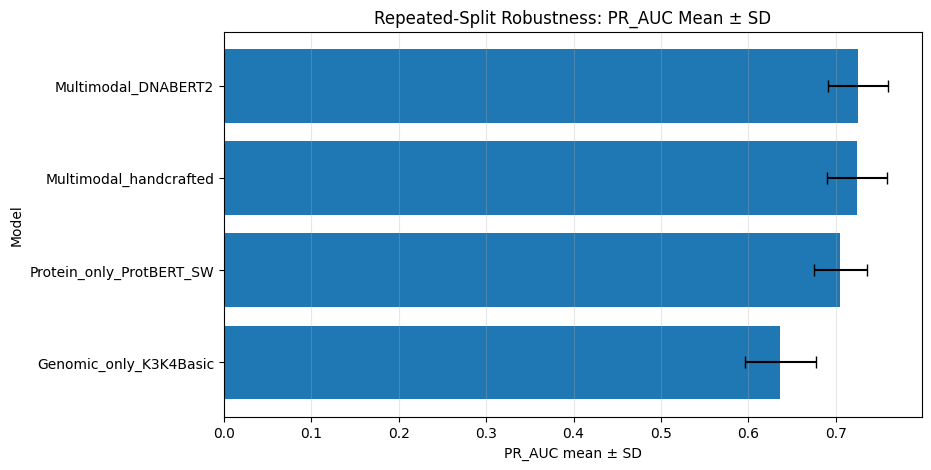

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_pr_auc_mean_sd_across_seeds.png


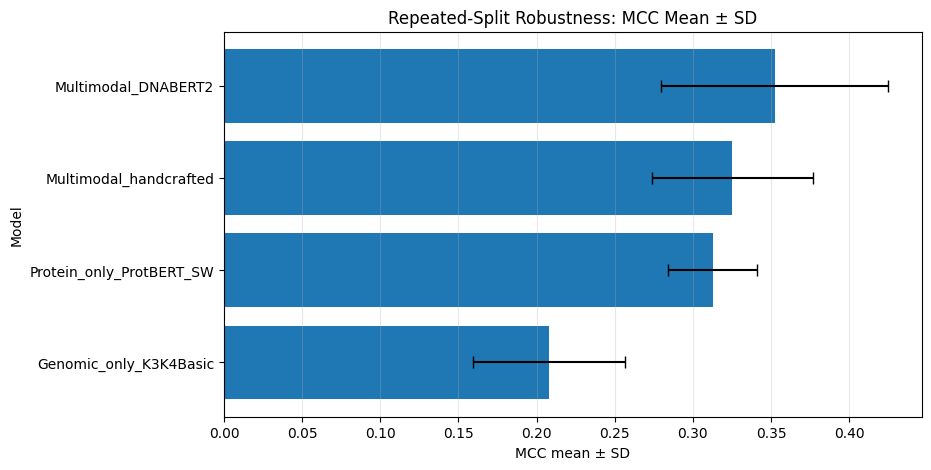

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_mcc_mean_sd_across_seeds.png


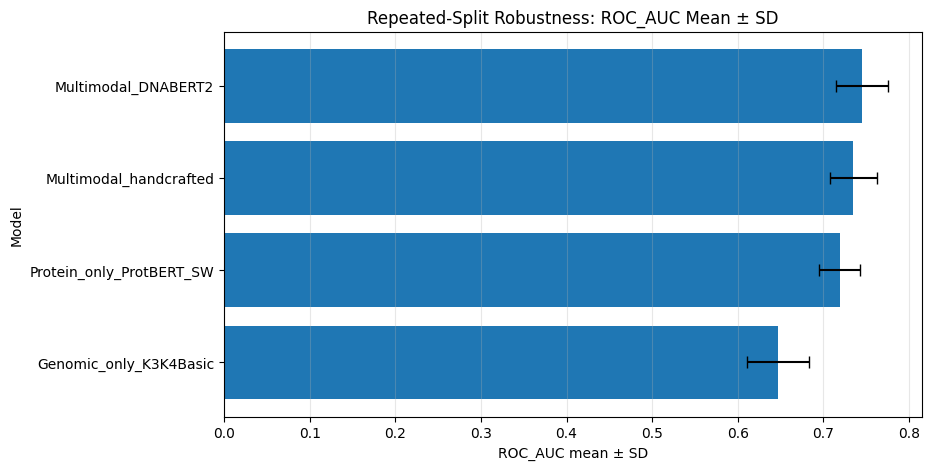

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_roc_auc_mean_sd_across_seeds.png


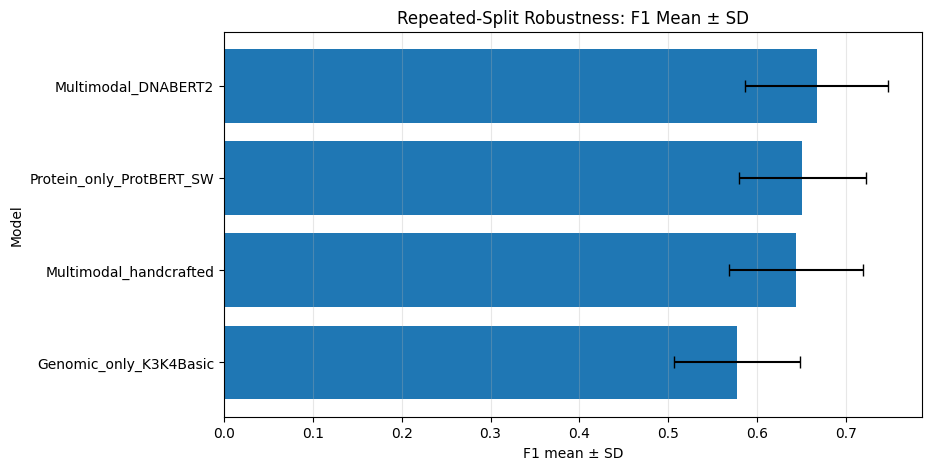

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_f1_mean_sd_across_seeds.png


In [20]:
# ============================================================
# FIGURE 1 — MEAN ± SD PERFORMANCE BARPLOTS
# ============================================================

def plot_mean_sd_metric(summary_df, metric, output_path):
    mean_col = f"{metric}_mean"
    sd_col = f"{metric}_sd"

    plot_df = summary_df.sort_values(mean_col, ascending=True).copy()

    plt.figure(figsize=(9, 5))

    plt.barh(
        plot_df["model_key"],
        plot_df[mean_col],
        xerr=plot_df[sd_col],
        capsize=4
    )

    plt.xlabel(f"{metric.upper()} mean ± SD")
    plt.ylabel("Model")
    plt.title(f"Repeated-Split Robustness: {metric.upper()} Mean ± SD")
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_mean_sd_metric(
    summary_mean_sd_df,
    metric="pr_auc",
    output_path=FIGURE_DIR / "phase11_pr_auc_mean_sd_across_seeds.png"
)

plot_mean_sd_metric(
    summary_mean_sd_df,
    metric="mcc",
    output_path=FIGURE_DIR / "phase11_mcc_mean_sd_across_seeds.png"
)

plot_mean_sd_metric(
    summary_mean_sd_df,
    metric="roc_auc",
    output_path=FIGURE_DIR / "phase11_roc_auc_mean_sd_across_seeds.png"
)

plot_mean_sd_metric(
    summary_mean_sd_df,
    metric="f1",
    output_path=FIGURE_DIR / "phase11_f1_mean_sd_across_seeds.png"
)

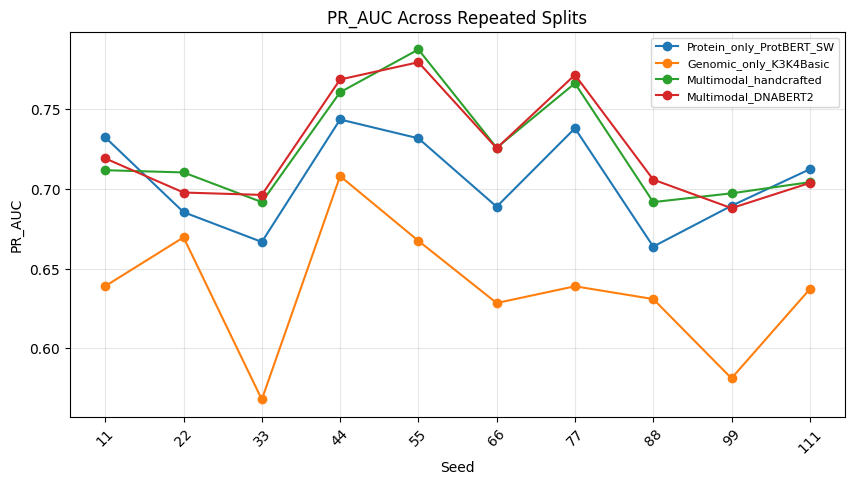

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_pr_auc_by_seed.png


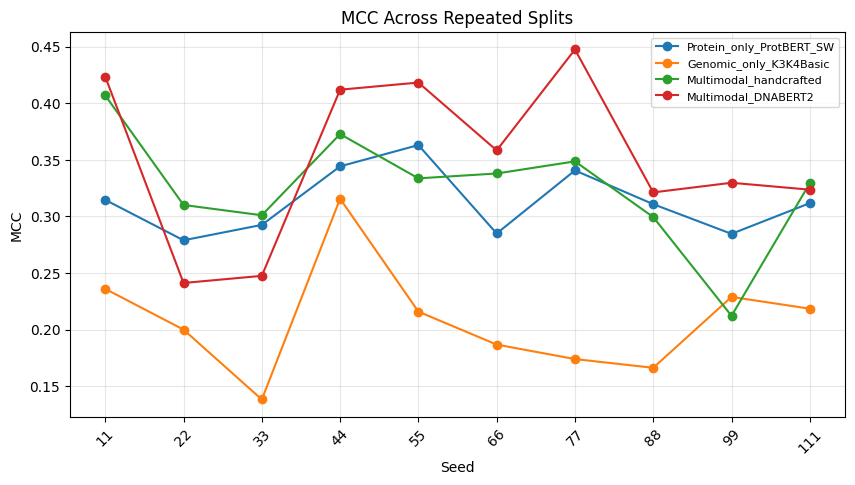

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_mcc_by_seed.png


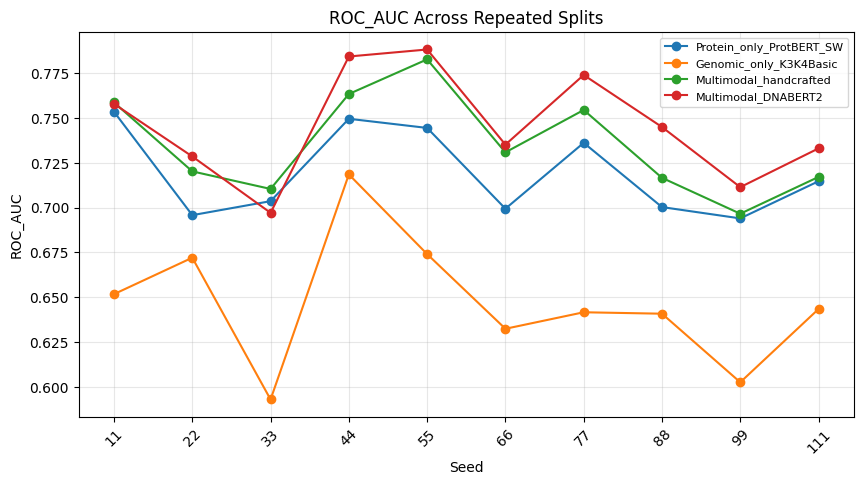

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_roc_auc_by_seed.png


In [21]:
# ============================================================
# FIGURE 2 — PER-SEED METRIC STABILITY LINES
# ============================================================

def plot_metric_by_seed(run_df, metric, output_path):
    plt.figure(figsize=(10, 5))

    for model_key in FEATURE_SETS.keys():
        sub = run_df[run_df["model_key"] == model_key].sort_values("seed")
        plt.plot(
            sub["seed"].astype(str),
            sub[metric],
            marker="o",
            label=model_key
        )

    plt.xlabel("Seed")
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} Across Repeated Splits")
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


plot_metric_by_seed(
    run_results_df,
    metric="pr_auc",
    output_path=FIGURE_DIR / "phase11_pr_auc_by_seed.png"
)

plot_metric_by_seed(
    run_results_df,
    metric="mcc",
    output_path=FIGURE_DIR / "phase11_mcc_by_seed.png"
)

plot_metric_by_seed(
    run_results_df,
    metric="roc_auc",
    output_path=FIGURE_DIR / "phase11_roc_auc_by_seed.png"
)

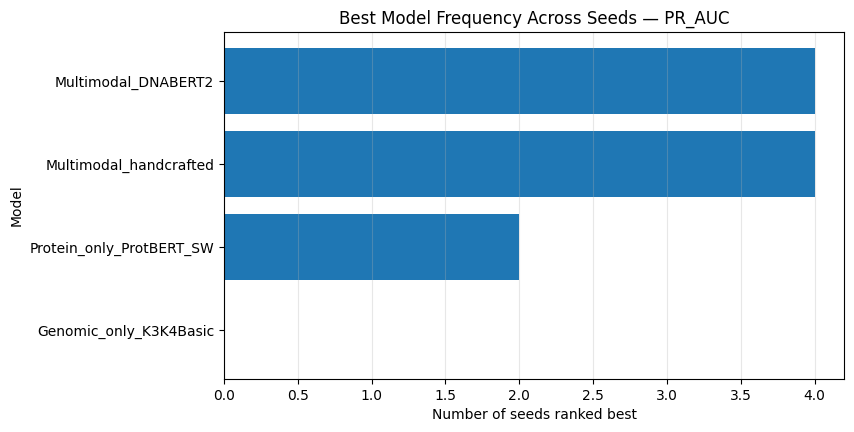

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_best_model_frequency_pr_auc.png


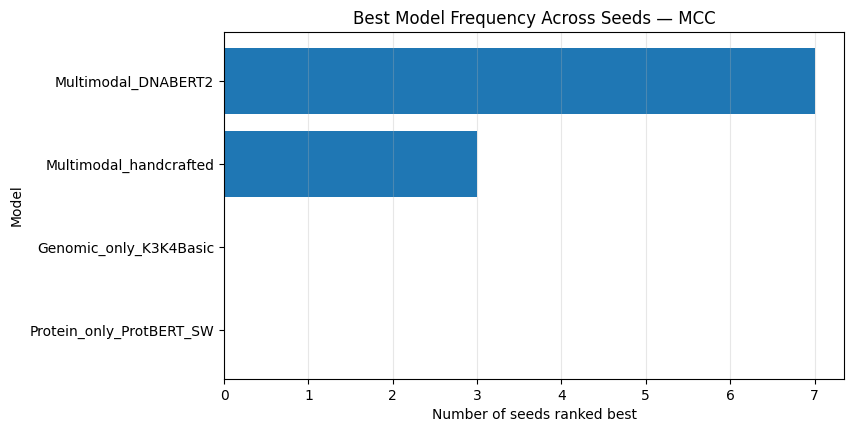

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_best_model_frequency_mcc.png


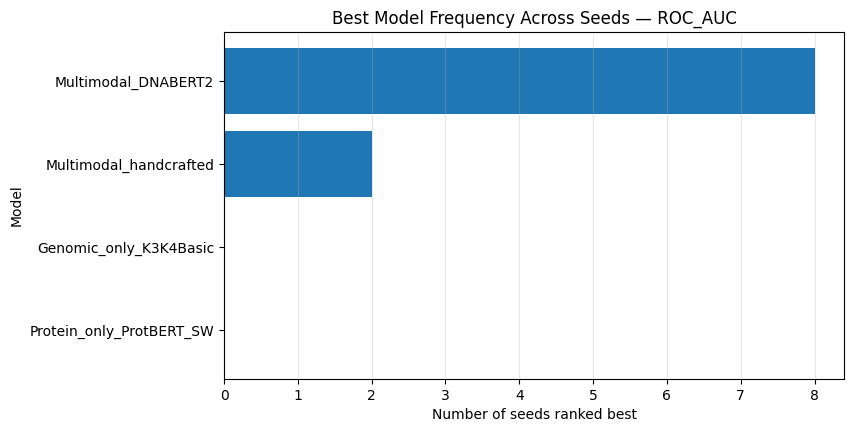

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_best_model_frequency_roc_auc.png


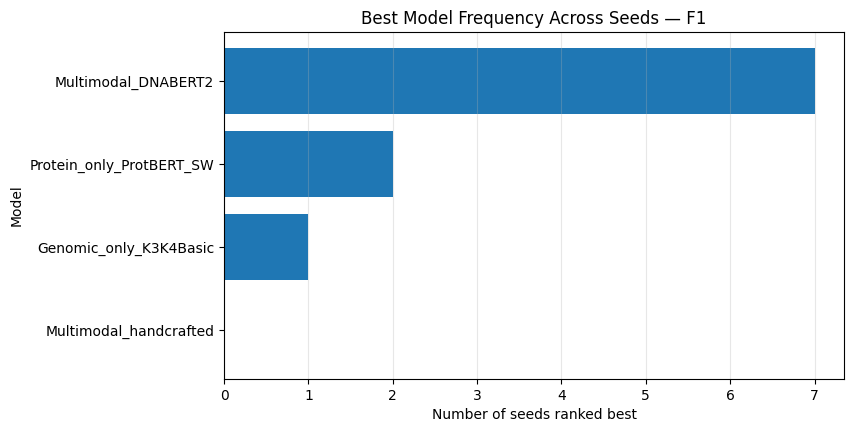

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_best_model_frequency_f1.png


In [22]:
# ============================================================
# FIGURE 3 — BEST MODEL FREQUENCY
# ============================================================

for metric in ["pr_auc", "mcc", "roc_auc", "f1"]:
    plot_df = best_model_frequency_df[
        best_model_frequency_df["metric"] == metric
    ].copy()

    plot_df = plot_df.sort_values("n_times_best", ascending=True)

    plt.figure(figsize=(8, 4.5))
    plt.barh(plot_df["model_key"], plot_df["n_times_best"])
    plt.xlabel("Number of seeds ranked best")
    plt.ylabel("Model")
    plt.title(f"Best Model Frequency Across Seeds — {metric.upper()}")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / f"phase11_best_model_frequency_{metric}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

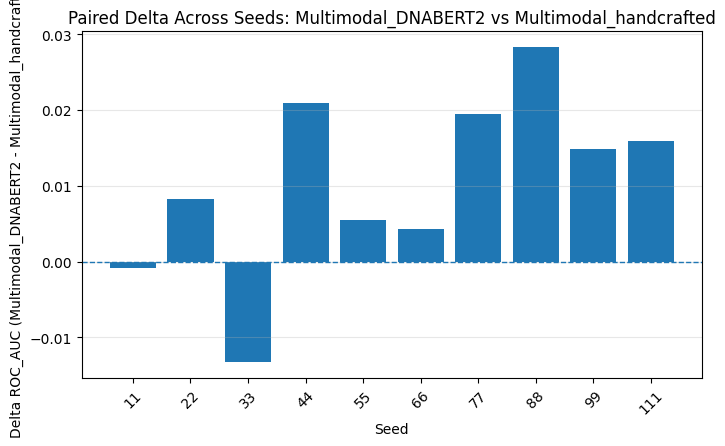

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_delta_roc_auc_dnabert2_minus_handcrafted.png


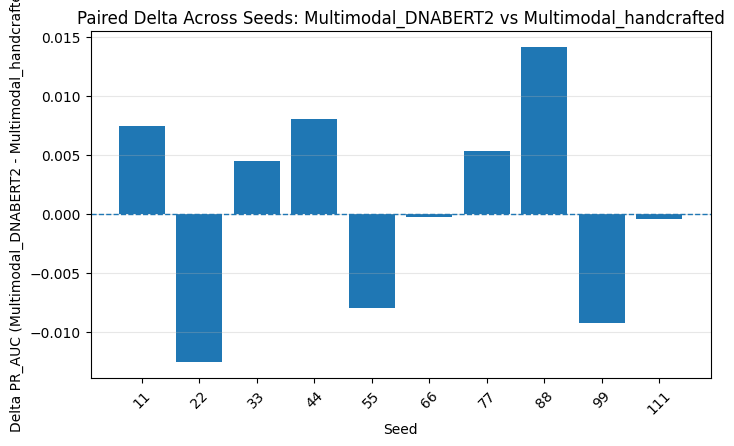

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_delta_pr_auc_dnabert2_minus_handcrafted.png


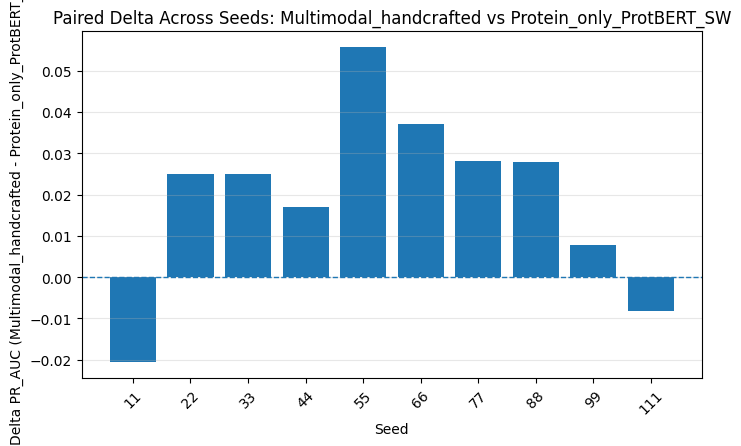

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_delta_pr_auc_handcrafted_minus_protein.png


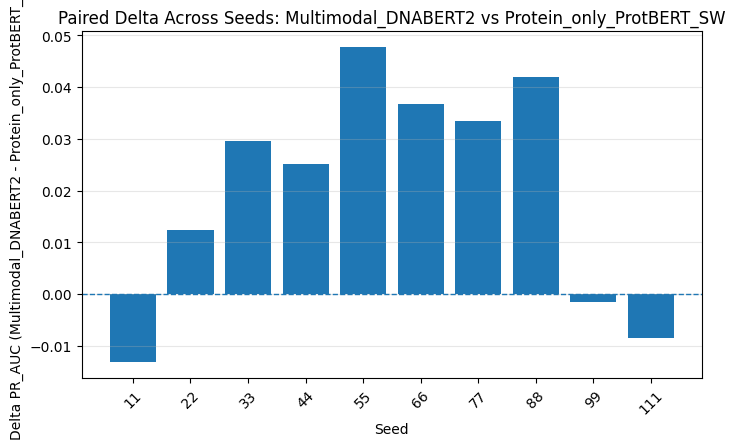

Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/figures/phase11_delta_pr_auc_dnabert2_minus_protein.png


In [23]:
# ============================================================
# FIGURE 4 — PAIRED DELTAS ACROSS SEEDS
# ============================================================

def plot_paired_delta(model_a, model_b, metric, output_path):
    a = run_results_df[
        run_results_df["model_key"] == model_a
    ][["seed", metric]].rename(columns={metric: "metric_a"})

    b = run_results_df[
        run_results_df["model_key"] == model_b
    ][["seed", metric]].rename(columns={metric: "metric_b"})

    merged = a.merge(b, on="seed", how="inner")
    merged["delta_b_minus_a"] = merged["metric_b"] - merged["metric_a"]

    plt.figure(figsize=(8, 4.5))
    plt.bar(merged["seed"].astype(str), merged["delta_b_minus_a"])
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.xlabel("Seed")
    plt.ylabel(f"Delta {metric.upper()} ({model_b} - {model_a})")
    plt.title(f"Paired Delta Across Seeds: {model_b} vs {model_a}")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


# Most important comparisons
plot_paired_delta(
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
    "roc_auc",
    FIGURE_DIR / "phase11_delta_roc_auc_dnabert2_minus_handcrafted.png"
)

plot_paired_delta(
    "Multimodal_handcrafted",
    "Multimodal_DNABERT2",
    "pr_auc",
    FIGURE_DIR / "phase11_delta_pr_auc_dnabert2_minus_handcrafted.png"
)

plot_paired_delta(
    "Protein_only_ProtBERT_SW",
    "Multimodal_handcrafted",
    "pr_auc",
    FIGURE_DIR / "phase11_delta_pr_auc_handcrafted_minus_protein.png"
)

plot_paired_delta(
    "Protein_only_ProtBERT_SW",
    "Multimodal_DNABERT2",
    "pr_auc",
    FIGURE_DIR / "phase11_delta_pr_auc_dnabert2_minus_protein.png"
)

In [24]:
# ============================================================
# PHASE 11 FINAL CLAIMS TABLE
# ============================================================

# Pull best model by primary metrics
best_pr_model = summary_mean_sd_df.sort_values("pr_auc_mean", ascending=False).iloc[0]
best_mcc_model = summary_mean_sd_df.sort_values("mcc_mean", ascending=False).iloc[0]
best_roc_model = summary_mean_sd_df.sort_values("roc_auc_mean", ascending=False).iloc[0]

dnabert_vs_hand_roc = paired_seed_comparison_df[
    (paired_seed_comparison_df["model_a"] == "Multimodal_handcrafted") &
    (paired_seed_comparison_df["model_b"] == "Multimodal_DNABERT2") &
    (paired_seed_comparison_df["metric"] == "roc_auc")
]

dnabert_vs_hand_pr = paired_seed_comparison_df[
    (paired_seed_comparison_df["model_a"] == "Multimodal_handcrafted") &
    (paired_seed_comparison_df["model_b"] == "Multimodal_DNABERT2") &
    (paired_seed_comparison_df["metric"] == "pr_auc")
]

phase11_claims_df = pd.DataFrame([
    {
        "claim": "Repeated-split evaluation addresses the single-test-split vulnerability.",
        "evidence": f"Models were evaluated across {len(REPEATED_SPLIT_SEEDS)} stratified train/validation/test splits.",
        "interpretation": "Mean ± SD across seeds provides a more robust estimate than a single held-out split."
    },
    {
        "claim": "PR-AUC was treated as the primary ranking metric.",
        "evidence": f"The highest mean PR-AUC model was {best_pr_model['model_key']} with PR-AUC mean={best_pr_model['pr_auc_mean']:.4f}, SD={best_pr_model['pr_auc_sd']:.4f}.",
        "interpretation": "This avoids cherry-picking ROC-AUC as the sole basis for model selection."
    },
    {
        "claim": "MCC was treated as the primary threshold-dependent metric.",
        "evidence": f"The highest mean MCC model was {best_mcc_model['model_key']} with MCC mean={best_mcc_model['mcc_mean']:.4f}, SD={best_mcc_model['mcc_sd']:.4f}.",
        "interpretation": "MCC provides a balanced summary of threshold-dependent classification behaviour."
    },
    {
        "claim": "ROC-AUC was treated as a secondary global ranking metric.",
        "evidence": f"The highest mean ROC-AUC model was {best_roc_model['model_key']} with ROC-AUC mean={best_roc_model['roc_auc_mean']:.4f}, SD={best_roc_model['roc_auc_sd']:.4f}.",
        "interpretation": "If DNABERT-2 remains high in ROC-AUC, it supports the global-ranking extension narrative; otherwise the claim should be softened further."
    },
    {
        "claim": "DNABERT-2 should not be described as a clear winner unless repeated splits confirm consistent superiority.",
        "evidence": "The interpretation should depend on mean ± SD and seed-level paired deltas.",
        "interpretation": "Use cautious language: small/global ranking gain, not clear dominance."
    }
])

display(phase11_claims_df)

claims_path = RESULT_DIR / "phase11_final_claims_table.csv"
phase11_claims_df.to_csv(claims_path, index=False)

print("Saved:", claims_path)

,claim,evidence,interpretation
0,Repeated-split evaluation addresses the single-test-split vulnerability.,Models were evaluated across 10 stratified train/validation/test splits.,Mean ± SD across seeds provides a more robust estimate than a single held-out split.
1,PR-AUC was treated as the primary ranking metric.,"The highest mean PR-AUC model was Multimodal_DNABERT2 with PR-AUC mean=0.7256, SD=0.0347.",This avoids cherry-picking ROC-AUC as the sole basis for model selection.
2,MCC was treated as the primary threshold-dependent metric.,"The highest mean MCC model was Multimodal_DNABERT2 with MCC mean=0.3522, SD=0.0728.",MCC provides a balanced summary of threshold-dependent classification behaviour.
3,ROC-AUC was treated as a secondary global ranking metric.,"The highest mean ROC-AUC model was Multimodal_DNABERT2 with ROC-AUC mean=0.7454, SD=0.0304.","If DNABERT-2 remains high in ROC-AUC, it supports the global-ranking extension narrative; otherwise the claim should be softened further."
4,DNABERT-2 should not be described as a clear winner unless repeated splits confirm consistent superiority.,The interpretation should depend on mean ± SD and seed-level paired deltas.,"Use cautious language: small/global ranking gain, not clear dominance."


Saved: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_final_claims_table.csv


In [25]:
# ============================================================
# EXPORT PHASE 11 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase11_repeated_split_robustness_tables.xlsx"

excel_tables = {
    "Raw_Results": run_results_df,
    "Mean_SD_Summary": summary_mean_sd_df,
    "Publication_Table": publication_summary_df,
    "Ranking_Per_Seed": ranking_per_seed_df,
    "Best_Model_Frequency": best_model_frequency_df,
    "Paired_Comparisons": paired_seed_comparison_df,
    "Metric_Decision": metric_decision_df,
    "Stability_Interpretation": stability_interpretation_df,
    "Claims": phase11_claims_df,
    "Split_Composition": split_composition_df,
}

if "fdr_df" in globals():
    excel_tables["Phase7_FDR_Correction"] = fdr_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/excel/phase11_repeated_split_robustness_tables.xlsx


In [26]:
# ============================================================
# AUTO-GENERATE PHASE 11 REPORT SUMMARY
# ============================================================

best_pr = summary_mean_sd_df.sort_values("pr_auc_mean", ascending=False).iloc[0]
best_mcc = summary_mean_sd_df.sort_values("mcc_mean", ascending=False).iloc[0]
best_roc = summary_mean_sd_df.sort_values("roc_auc_mean", ascending=False).iloc[0]

report_text = f"""
# Phase 11 — Repeated-Split / Multi-Seed Robustness Evaluation

## Objective

Phase 11 addressed the main statistical vulnerability identified in the supervisor feedback: the previous comparison relied on a single held-out test split. Although bootstrap confidence intervals estimate uncertainty within that test set, they do not capture variation across different train/test splits or random seeds. Therefore, this phase repeated the evaluation across multiple stratified splits.

## Experimental Design

Number of repeated seeds: {len(REPEATED_SPLIT_SEEDS)}

Seeds used:
{REPEATED_SPLIT_SEEDS}

Split ratio:
- Train: {TRAIN_SIZE:.2f}
- Validation: {VAL_SIZE:.2f}
- Test: {TEST_SIZE:.2f}

Models evaluated:
1. Protein-only ProtBERT-SW
2. Genomic-only K3/K4/Basic
3. Multimodal handcrafted: ProtBERT-SW + K3/K4/Basic
4. Multimodal DNABERT-2: ProtBERT-SW + DNABERT-2

Primary ranking metric:
- PR-AUC

Primary threshold-dependent metric:
- MCC

Secondary metrics:
- ROC-AUC
- F1

Thresholds for classification metrics were selected on the validation set using {THRESHOLD_SELECTION_METRIC.upper()}, then evaluated on the test set.

## Main Results

Best mean PR-AUC model:
- {best_pr['model_key']}
- PR-AUC mean = {best_pr['pr_auc_mean']:.4f}
- PR-AUC SD = {best_pr['pr_auc_sd']:.4f}

Best mean MCC model:
- {best_mcc['model_key']}
- MCC mean = {best_mcc['mcc_mean']:.4f}
- MCC SD = {best_mcc['mcc_sd']:.4f}

Best mean ROC-AUC model:
- {best_roc['model_key']}
- ROC-AUC mean = {best_roc['roc_auc_mean']:.4f}
- ROC-AUC SD = {best_roc['roc_auc_sd']:.4f}

## Interpretation

This repeated-split analysis should be used to determine whether the single-test-set conclusions remain stable. If DNABERT-2 remains the highest ROC-AUC model across repeated splits, the interpretation can be that DNABERT-2 provides a small but more robust global-ranking gain. However, if the ranking changes across seeds, the language should be softened further and the main manuscript story should emphasize the ranking-versus-interpretability trade-off rather than model superiority.

## Reviewer-Relevant Contribution

This phase directly addresses the concern that model rankings may depend on a single train/test split. Reporting mean ± SD across repeated seeds makes the statistical evidence more publication-ready and reduces the vulnerability of relying only on bootstrap confidence intervals from one held-out test set.
"""

report_path = REPORT_DIR / "phase11_repeated_split_robustness_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved report:", report_path)


# Phase 11 — Repeated-Split / Multi-Seed Robustness Evaluation

## Objective

Phase 11 addressed the main statistical vulnerability identified in the supervisor feedback: the previous comparison relied on a single held-out test split. Although bootstrap confidence intervals estimate uncertainty within that test set, they do not capture variation across different train/test splits or random seeds. Therefore, this phase repeated the evaluation across multiple stratified splits.

## Experimental Design

Number of repeated seeds: 10

Seeds used:
[11, 22, 33, 44, 55, 66, 77, 88, 99, 111]

Split ratio:
- Train: 0.70
- Validation: 0.15
- Test: 0.15

Models evaluated:
1. Protein-only ProtBERT-SW
2. Genomic-only K3/K4/Basic
3. Multimodal handcrafted: ProtBERT-SW + K3/K4/Basic
4. Multimodal DNABERT-2: ProtBERT-SW + DNABERT-2

Primary ranking metric:
- PR-AUC

Primary threshold-dependent metric:
- MCC

Secondary metrics:
- ROC-AUC
- F1

Thresholds for classification metrics were selected on the 

In [27]:
# ============================================================
# LIST OUTPUTS
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== MODEL FILES ===")
for p in sorted(MODEL_DIR.glob("*"))[:20]:
    print(p)
if len(list(MODEL_DIR.glob("*"))) > 20:
    print("... more model files omitted")

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_best_model_frequency_by_metric.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_final_claims_table.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_metric_priority_decision_table.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_model_ranking_per_seed.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_paired_comparison_across_seeds.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_phase7_pairwise_pvalues_with_bh_fdr.csv
/content/drive/MyDrive/Project_Protein/model/phase11_repeated_split_seed_robustness/results/phase11_publication_style_mean_sd_table.csv
/content/drive/MyDrive/Project_Protein/model/pha

In [28]:
display(publication_summary_df)
display(summary_mean_sd_df)
display(best_model_frequency_df)
display(paired_seed_comparison_df)
display(phase11_claims_df)
display(metric_decision_df)

,Model,Description,ROC-AUC mean ± SD,PR-AUC mean ± SD,F1 mean ± SD,MCC mean ± SD,Accuracy mean ± SD,Specificity mean ± SD,Recall mean ± SD,n_runs
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,0.745 ± 0.030,0.726 ± 0.035,0.667 ± 0.081,0.352 ± 0.073,0.670 ± 0.038,0.652 ± 0.139,0.688 ± 0.158,10
1,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,0.735 ± 0.028,0.725 ± 0.034,0.644 ± 0.076,0.325 ± 0.052,0.656 ± 0.027,0.664 ± 0.138,0.648 ± 0.163,10
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,0.719 ± 0.024,0.705 ± 0.030,0.651 ± 0.071,0.313 ± 0.029,0.649 ± 0.013,0.617 ± 0.143,0.681 ± 0.157,10
3,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,0.647 ± 0.036,0.637 ± 0.041,0.577 ± 0.071,0.208 ± 0.049,0.596 ± 0.023,0.616 ± 0.200,0.577 ± 0.179,10


,model_key,model_description,n_runs,roc_auc_mean,roc_auc_sd,roc_auc_median,roc_auc_min,roc_auc_max,pr_auc_mean,pr_auc_sd,pr_auc_median,pr_auc_min,pr_auc_max,accuracy_mean,accuracy_sd,accuracy_median,accuracy_min,accuracy_max,precision_mean,precision_sd,precision_median,precision_min,precision_max,recall_sensitivity_mean,recall_sensitivity_sd,recall_sensitivity_median,recall_sensitivity_min,recall_sensitivity_max,specificity_mean,specificity_sd,specificity_median,specificity_min,specificity_max,f1_mean,f1_sd,f1_median,f1_min,f1_max,mcc_mean,mcc_sd,mcc_median,mcc_min,mcc_max
0,Multimodal_DNABERT2,ProtBERT-SW + DNABERT-2 genomic embedding,10,0.7454,0.0304,0.7400,0.6971,0.7881,0.7256,0.0347,0.7126,0.6880,0.7795,0.6697,0.0385,0.6716,0.6015,0.7159,0.6744,0.0549,0.6687,0.5789,0.7921,0.6880,0.1577,0.6852,0.3382,0.8603,0.6519,0.1389,0.6434,0.4118,0.8667,0.6672,0.0805,0.6760,0.4600,0.7429,0.3522,0.0728,0.3440,0.2412,0.4474
1,Multimodal_handcrafted,ProtBERT-SW + handcrafted K3/K4/Basic genomic features,10,0.7351,0.0278,0.7255,0.6966,0.7826,0.7248,0.0344,0.7111,0.6918,0.7875,0.6557,0.0266,0.6494,0.5978,0.7011,0.6703,0.0556,0.6558,0.6041,0.8060,0.6482,0.1629,0.6852,0.3971,0.8750,0.6636,0.1378,0.6287,0.4222,0.9037,0.6436,0.0757,0.6619,0.5068,0.7235,0.3252,0.0516,0.3314,0.2122,0.4068
2,Protein_only_ProtBERT_SW,Protein-only ProtBERT sliding-window embedding,10,0.7191,0.0240,0.7091,0.6940,0.7534,0.7053,0.0301,0.7010,0.6639,0.7436,0.6491,0.0133,0.6458,0.6273,0.6716,0.6547,0.0613,0.6308,0.6077,0.8036,0.6811,0.1569,0.6937,0.3333,0.8382,0.6170,0.1427,0.5903,0.4779,0.9191,0.6510,0.0714,0.6596,0.4712,0.7192,0.3126,0.0287,0.3113,0.2789,0.3630
3,Genomic_only_K3K4Basic,Genomic-only handcrafted K3/K4/Basic regulatory features extracted from combined matrix,10,0.6471,0.0360,0.6426,0.5931,0.7185,0.6369,0.0409,0.6381,0.5680,0.7081,0.5963,0.0230,0.5960,0.5683,0.6384,0.6191,0.0650,0.6186,0.5398,0.7681,0.5773,0.1791,0.5388,0.3382,0.9037,0.6157,0.2000,0.6606,0.2353,0.8824,0.5771,0.0711,0.5812,0.4444,0.6759,0.2080,0.0486,0.2080,0.1383,0.3156


,metric,model_key,n_times_best,n_seeds,fraction_best
0,pr_auc,Protein_only_ProtBERT_SW,2,10,0.2
1,pr_auc,Genomic_only_K3K4Basic,0,10,0.0
2,pr_auc,Multimodal_handcrafted,4,10,0.4
3,pr_auc,Multimodal_DNABERT2,4,10,0.4
4,mcc,Protein_only_ProtBERT_SW,0,10,0.0
5,mcc,Genomic_only_K3K4Basic,0,10,0.0
6,mcc,Multimodal_handcrafted,3,10,0.3
7,mcc,Multimodal_DNABERT2,7,10,0.7
8,roc_auc,Protein_only_ProtBERT_SW,0,10,0.0
9,roc_auc,Genomic_only_K3K4Basic,0,10,0.0


,model_a,model_b,metric,n_paired_seeds,metric_a_mean,metric_b_mean,delta_mean,delta_sd,delta_median,n_seeds_better,n_seeds_worse,n_seeds_equal,delta_values
0,Protein_only_ProtBERT_SW,Multimodal_handcrafted,pr_auc,10,0.7053,0.7248,0.0195,0.0219,0.0250,8,2,0,-0.020600;0.024900;0.025000;0.017100;0.055700;0.037000;0.028200;0.027900;0.007800;-0.008100
1,Protein_only_ProtBERT_SW,Multimodal_handcrafted,mcc,10,0.3126,0.3252,0.0126,0.0450,0.0131,7,3,0,0.092200;0.031200;0.008500;0.028500;-0.029400;0.053000;0.008000;-0.011400;-0.072400;0.017600
2,Protein_only_ProtBERT_SW,Multimodal_handcrafted,roc_auc,10,0.7191,0.7351,0.0159,0.0124,0.0150,10,0,0,0.005200;0.024400;0.006800;0.013800;0.038200;0.031400;0.018300;0.016300;0.002600;0.002400
3,Protein_only_ProtBERT_SW,Multimodal_handcrafted,f1,10,0.6510,0.6436,-0.0074,0.0885,-0.0055,4,6,0,0.032700;-0.062900;0.009600;0.005900;-0.004500;-0.006600;-0.084000;-0.039200;-0.127200;0.202600
4,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,pr_auc,10,0.7053,0.7256,0.0203,0.0218,0.0273,7,3,0,-0.013200;0.012300;0.029500;0.025100;0.047700;0.036700;0.033500;0.042000;-0.001500;-0.008600
5,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,mcc,10,0.3126,0.3522,0.0397,0.0540,0.0502,8,2,0,0.108800;-0.037700;-0.045000;0.067700;0.055200;0.073400;0.106800;0.010400;0.045100;0.011900
6,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,roc_auc,10,0.7191,0.7454,0.0263,0.0172,0.0337,9,1,0,0.004400;0.032700;-0.006500;0.034700;0.043700;0.035700;0.037800;0.044600;0.017400;0.018300
7,Protein_only_ProtBERT_SW,Multimodal_DNABERT2,f1,10,0.6510,0.6672,0.0163,0.1006,0.0185,8,2,0,0.052100;-0.202100;0.019800;0.023100;0.014100;0.016900;0.059100;-0.044700;0.017300;0.207100
8,Genomic_only_K3K4Basic,Multimodal_handcrafted,pr_auc,10,0.6369,0.7248,0.0878,0.0327,0.0851,10,0,0,0.072700;0.040700;0.123800;0.052600;0.120000;0.097400;0.127300;0.060800;0.116000;0.067100
9,Genomic_only_K3K4Basic,Multimodal_handcrafted,mcc,10,0.2080,0.3252,0.1171,0.0589,0.1254,9,1,0,0.170800;0.110100;0.162700;0.057100;0.117700;0.151100;0.174600;0.133100;-0.016700;0.110800


,claim,evidence,interpretation
0,Repeated-split evaluation addresses the single-test-split vulnerability.,Models were evaluated across 10 stratified train/validation/test splits.,Mean ± SD across seeds provides a more robust estimate than a single held-out split.
1,PR-AUC was treated as the primary ranking metric.,"The highest mean PR-AUC model was Multimodal_DNABERT2 with PR-AUC mean=0.7256, SD=0.0347.",This avoids cherry-picking ROC-AUC as the sole basis for model selection.
2,MCC was treated as the primary threshold-dependent metric.,"The highest mean MCC model was Multimodal_DNABERT2 with MCC mean=0.3522, SD=0.0728.",MCC provides a balanced summary of threshold-dependent classification behaviour.
3,ROC-AUC was treated as a secondary global ranking metric.,"The highest mean ROC-AUC model was Multimodal_DNABERT2 with ROC-AUC mean=0.7454, SD=0.0304.","If DNABERT-2 remains high in ROC-AUC, it supports the global-ranking extension narrative; otherwise the claim should be softened further."
4,DNABERT-2 should not be described as a clear winner unless repeated splits confirm consistent superiority.,The interpretation should depend on mean ± SD and seed-level paired deltas.,"Use cautious language: small/global ranking gain, not clear dominance."


,metric,role,justification
0,PR-AUC,Primary ranking metric,The project aims to prioritise biologically meaningful T2D-associated genes/proteins. PR-AUC is more sensitive to the quality of positive candidate ranking than accuracy.
1,MCC,Primary threshold-dependent metric,"MCC accounts for TP, TN, FP and FN simultaneously and is more informative than accuracy when evaluating balanced binary classification quality."
2,ROC-AUC,Secondary ranking metric,"ROC-AUC measures global positive-vs-negative ranking, but it should not be the only basis for model selection because PR-AUC and top-ranked biological quality are central to this project."
3,F1,Secondary threshold-dependent metric,"F1 summarizes precision and recall for the positive class, but it ignores true negatives. Therefore it is secondary to MCC."
